# GPU Logistic Regression Stacker for Playground S6E6

Kaggle's June Playground competition uses metric `balanced accuracy`. Therefore a great stacker to combine/ensemble models is a GPU accelerated multi-class logistic regression stacker. We just load in our OOF and Test PREDS from our models and run this notebook. There is no need to calibrate output predicted probabilities since multi-nominal logistic regression already does this. Also we do not need to calibrate the input probabilities fed into logistic regression. We just feed raw predictions into logistic regression!

In `Version 2` of this logistic regression stacker, we load
* Vladimir's ( @yekenot ) RealMLP (v12) from [here][1] (in dataset [here][28])
* Don's ( @donmarch14 ) TabM (v2) from [here][2] (in dataset [here][28])
* Don's ( @donmarch14 ) XGBoost (v1) from [here][3] (copied [here][17])
* Don's ( @donmarch14 ) CatBoost (v2) from [here][4] (copied [here][18])
* Codex's RealMLP_v1 from [here][5]
* Codex's XGBoost_v1 from [here][6]

In `Version 3` we add 6 more models:
* Kaggler ( @nawfeelrahman1124444 ) RealMLP (v10) from [here][13] (in dataset [here][28])
* Mikhail ( @mikhailnaumov ) XGBoost (v2) from [here][15] (copied [here][16])
* Codex's TabICLv2 from [here][10]
* Codex's LGBM_v3 from [here][11]
* Codex's Log Reg v1 from [here][12]
* Codex's NN_v1 from [here][14]

In `Version 4` we add my new `LB 0.96801` XGB:
* Codex's XGBoost_v5 from [here][19]

In `Version 6` we add 2 more models including my new `LB 0.96979` RealMLP!:
* Codex's RealMLP_v5 [here][20]
* Codex's NN_v2 [here][21]

In `Version 7` we add my new `LB 0.96972` CAT:
* Codex's CatBoost_v3 from [here][22]

In `Version 8` we add 3 more models including Cstdy's `one-vs-rest` models:
* Omid ( @omidbaghchehsaraei ) LGBM (v1) from [here][24] (in dataset [here][28])
* Cstdy ( @kirill0212 ) XGBoost (v1) from [here][26] (in dataset [here][28])
* Cstdy ( @kirill0212 ) TabM (v1) from [here][27] (in dataset [here][28])

In `Version 9` we load (other Kagglers') OOF and Test PREDS from dataset [here][28] for correct notebook versions.

To improve this notebook's CV and LB score, just create more models and add their OOF and Test PREDS to a forked copy of this notebook! Discussion about this notebook is [here][9]. Good luck, have fun!

[1]: https://www.kaggle.com/code/yekenot/ps-s6-e6-realmlp-pytorch?scriptVersionId=324087390
[2]: https://www.kaggle.com/code/donmarch14/s6e6-tabm?scriptVersionId=323695236
[3]: https://www.kaggle.com/code/donmarch14/s6e6-xgboost?scriptVersionId=323616155
[4]: https://www.kaggle.com/code/donmarch14/s6e6-catboost?scriptVersionId=323646390
[5]: https://www.kaggle.com/code/cdeotte/realmlp-v1-for-s6e6
[6]: https://www.kaggle.com/code/cdeotte/xgb-v1-for-s6e6
[7]: https://www.kaggle.com/code/cdeotte/lgbm-v1-for-s6e6
[8]: https://www.kaggle.com/code/cdeotte/realmlp-v2-for-s6e6
[9]: https://www.kaggle.com/competitions/playground-series-s6e6/discussion/704014
[10]: https://www.kaggle.com/code/cdeotte/tabicl-v2-for-s6e6/notebook
[11]: https://www.kaggle.com/code/cdeotte/lgbm-v3-for-s6e6
[12]: https://www.kaggle.com/code/cdeotte/logreg-v1-for-s6e6
[13]: https://www.kaggle.com/code/nawfeelrahman1124444/single-realmlp-0-96980-v10?scriptVersionId=324145704
[14]: https://www.kaggle.com/code/cdeotte/nn-v1-for-s6e6/notebook
[15]: https://www.kaggle.com/code/mikhailnaumov/stellar-class-xgb?scriptVersionId=324309248
[16]: https://www.kaggle.com/code/cdeotte/xgb-v3-for-s6e6
[17]: https://www.kaggle.com/code/cdeotte/xgb-v0-for-s6e6
[18]: https://www.kaggle.com/code/cdeotte/cat-v0-for-s6e6
[19]: https://www.kaggle.com/code/cdeotte/xgb-v5-for-s6e6
[20]: https://www.kaggle.com/code/cdeotte/realmlp-v5-for-s6e6/
[21]: https://www.kaggle.com/code/cdeotte/nn-v2-for-s6e6/
[22]: https://www.kaggle.com/code/cdeotte/cat-v3-for-s6e6
[23]: https://www.kaggle.com/code/cdeotte/single-lightgbm-lb-0-96728
[24]: https://www.kaggle.com/code/omidbaghchehsaraei/lightgbm-stellar-class-cv-0-96816-lb-0-96885?scriptVersionId=324816757
[25]: https://www.kaggle.com/code/evgendvorkin/single-lightgbm-lb-0-96728
[26]: https://www.kaggle.com/code/kirill0212/ps6e6-one-vs-rest-xgb?scriptVersionId=324872761
[27]: https://www.kaggle.com/code/kirill0212/ps6e6-one-vs-rest-tabm?scriptVersionId=324873119
[28]: https://www.kaggle.com/datasets/cdeotte/s6e6-oof-and-test-preds

In [1]:
import os
import sys
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

import gc
import time
from tqdm.notebook import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RED': '\033[31m',
    'RESET': '\033[0m'
}

N_FOLDS     = CFG['FOLDS']
N_SEEDS     = 5
SEEDS       = [42, 777, 1234, 24611, 0] # list(range(42, 42 + N_SEEDS))
EPS         = 1e-15
LOGIT_CLIP  = 30.0
epochs      = 1000
C           = 0.1

TARGET      = 'health_condition'
target_map  = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
inv_map     = {v: k for k, v in target_map.items()}
BOOST       = 1.0

VER         = 1

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Seeds: {SEEDS}')

class PyTorchMultiLogReg(nn.Module):
    def __init__(self, in_features, out_features=3):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        return self.linear(x)

# Format: ('MODEL_NAME', 'oof_file.npy', 'test_file.npy')
# Update paths here if your model outputs live in another folder.
# STACKING_FILES = [
#     ### Version 2 ###
#     ('xgb-0', '/kaggle/input/notebooks/cdeotte/xgb-v0-for-s6e6/oof_xgb_cv.csv', '/kaggle/input/notebooks/cdeotte/xgb-v0-for-s6e6/test_xgb_preds.csv'),
#     ('xgb-1', '/kaggle/input/notebooks/cdeotte/xgb-v1-for-s6e6/oof_preds.npy', '/kaggle/input/notebooks/cdeotte/xgb-v1-for-s6e6/test_preds.npy'),
#     ('realmlp-0', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_preds_realmlp0_v12.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_preds_realmlp0_v12.csv'),
#     ('realmlp-1', '/kaggle/input/notebooks/cdeotte/realmlp-v1-for-s6e6/oof_preds.npy', '/kaggle/input/notebooks/cdeotte/realmlp-v1-for-s6e6/test_preds.npy'),
#     ('tabm-0', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_preds_tabm0_v2.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_preds_tabm0_v2.csv'),
#     ('cat-0', '/kaggle/input/notebooks/cdeotte/cat-v0-for-s6e6/catboost_oof_predictions.csv', '/kaggle/input/notebooks/cdeotte/cat-v0-for-s6e6/catboost_test_predictions.csv'),
#     ### Version 3 ###
#     ('realmlp-2', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_preds_realmlp2_v10.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_preds_realmlp2_v10.csv'),
#     ('tabicl-2', '/kaggle/input/notebooks/cdeotte/tabicl-v2-for-s6e6/train_oof/tabicl-2_oof.npy', '/kaggle/input/notebooks/cdeotte/tabicl-v2-for-s6e6/test_preds/tabicl-2_test_preds.npy'),
#     ('lgbm-3', '/kaggle/input/notebooks/cdeotte/lgbm-v3-for-s6e6/train_oof/lgbm-3_oof.npy', '/kaggle/input/notebooks/cdeotte/lgbm-v3-for-s6e6/test_preds/lgbm-3_test_preds.npy'),
#     ('logreg-1', '/kaggle/input/notebooks/cdeotte/logreg-v1-for-s6e6/train_oof/logreg-1_oof.npy', '/kaggle/input/notebooks/cdeotte/logreg-v1-for-s6e6/test_preds/logreg-1_test_preds.npy'),
#     ('nn-1', '/kaggle/input/notebooks/cdeotte/nn-v1-for-s6e6/train_oof/nn-1_oof.npy', '/kaggle/input/notebooks/cdeotte/nn-v1-for-s6e6/test_preds/nn-1_test_preds.npy'),
#     ('xgb-3', '/kaggle/input/notebooks/cdeotte/xgb-v3-for-s6e6/stellar_class_xgb_oof_preds_raw.npy', '/kaggle/input/notebooks/cdeotte/xgb-v3-for-s6e6/stellar_class_xgb_test_preds_raw.npy'),
#     ### Version 4 ###
#     ('xgb-5', '/kaggle/input/notebooks/cdeotte/xgb-v5-for-s6e6/train_oof/xgb-5_oof.npy', '/kaggle/input/notebooks/cdeotte/xgb-v5-for-s6e6/test_preds/xgb-5_test_preds.npy'),
#     ### Version 6 ###
#     ('realmlp-5', '/kaggle/input/notebooks/cdeotte/realmlp-v5-for-s6e6/train_oof/realmlp-5_oof.npy', '/kaggle/input/notebooks/cdeotte/realmlp-v5-for-s6e6/test_preds/realmlp-5_test_preds.npy'),
#     ('nn-2', '/kaggle/input/notebooks/cdeotte/nn-v2-for-s6e6/train_oof/nn-2_oof.npy', '/kaggle/input/notebooks/cdeotte/nn-v2-for-s6e6/test_preds/nn-2_test_preds.npy'),
#     ### Version 7 ###
#     ('cat-3', '/kaggle/input/notebooks/cdeotte/cat-v3-for-s6e6/train_oof/cat-3_oof.npy', '/kaggle/input/notebooks/cdeotte/cat-v3-for-s6e6/test_preds/cat-3_test_preds.npy'),
#     ### Version 8 ###
#     ('lgbm-5', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_preds_lgbm5_v1.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_preds_lgbm5_v1.csv'),
#     ('xgb-6', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_final_xgb6_v1.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_final_xgb6_v1.csv'),
#     ('tabm-1', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_final_tabm1_v1.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_final_tabm1_v1.csv'),
# ]

# print(f'Total models: {len(STACKING_FILES)}')

Using device: cuda
Seeds: [42, 777, 1234, 24611, 0]


In [3]:
def dataloader(filepath, train_prefix, test_prefix):    
    # Store raw numpy arrays instead of DataFrames to save memory
    train_arrays = []
    train_cols = []
    
    test_arrays = []
    test_cols = []
    
    # Track file paths: {model_name: [oof_path, test_path]}
    model_groups = {}

    print("Loading numpy(.npy) files: ")
    for (root, dirs, files) in os.walk(filepath):
        print("\nLoading folder..", root)
        npy_files = [f for f in sorted(files) if f.endswith('.npy')]
        
        for file in tqdm(npy_files):
            full_path = os.path.join(root, file)
            
            # Memory optimization: Use mmap_mode if RAM is low, otherwise normal load
            arr = np.load(full_path, mmap_mode='r') 
            base_name = file.replace('.npy', '')
            col_names = [f"{base_name}_c{c}" for c in range(3)]

            # Extract model name by removing prefixes
            if train_prefix in file:
                train_arrays.append(arr)
                train_cols.extend(col_names)
                
                model_name = base_name.replace(train_prefix, '')
                if model_name not in model_groups:
                    model_groups[model_name] = [None, None]
                model_groups[model_name][0] = full_path
                
            elif test_prefix in file:
                test_arrays.append(arr)
                test_cols.extend(col_names)
                
                model_name = base_name.replace(test_prefix, '')
                if model_name not in model_groups:
                    model_groups[model_name] = [None, None]
                model_groups[model_name][1] = full_path
    
    # --- Check for Missing Files Alert ---
    missing_alerts = []
    stacking_files = []
    
    for model, paths in model_groups.items():
        oof_path, test_path = paths
        if oof_path and test_path:
            stacking_files.append((model, oof_path, test_path))
        else:
            missing_type = "Test" if not test_path else "OOF/Train"
            existing_path = oof_path if oof_path else test_path
            missing_alerts.append(f"⚠️ Model '{model}' is missing its {missing_type} file. Found: {existing_path}")
            
    if missing_alerts:
        print("\n[⚠️WARNING] Mismatched files detected:", file=sys.stderr)
        for alert in missing_alerts:
            print(alert, file=sys.stderr)
            
    # --- Memory Optimization: Efficient Concatenation ---
    # Combine via numpy first, then build DataFrame once to prevent fragmentation
    if train_arrays:
        train_matrix = np.column_stack(train_arrays)
        train_df = pd.DataFrame(train_matrix, columns=train_cols)
        train_df.columns = [c.replace(train_prefix, '') for c in train_df.columns]
    else:
        train_df = pd.DataFrame()

    if test_arrays:
        test_matrix = np.column_stack(test_arrays)
        test_df = pd.DataFrame(test_matrix, columns=test_cols)
        test_df.columns = [c.replace(test_prefix, '') for c in test_df.columns]
    else:
        test_df = pd.DataFrame()

    print(f"✅ Files loading complete!")

    return train_df, test_df, stacking_files

PATH = "/kaggle/input/datasets/"
train_df, test_df, STACKING_FILES = dataloader(PATH, "oof_", "test_")

Loading numpy(.npy) files: 

Loading folder.. /kaggle/input/datasets/


0it [00:00, ?it/s]


Loading folder.. /kaggle/input/datasets/sylvesterdalmeida


0it [00:00, ?it/s]


Loading folder.. /kaggle/input/datasets/sylvesterdalmeida/ps6e7-all-outputs


...


Loading folder.. /kaggle/input/datasets/sylvesterdalmeida/ps6e7-all-outputs/pytab/multi_seed


  0%|          | 0/6 [00:00<?, ?it/s]


Loading folder.. /kaggle/input/datasets/sylvesterdalmeida/ps6e7-all-outputs/pytab/single


  0%|          | 0/20 [00:00<?, ?it/s]

✅ Files loading complete!


In [4]:
print(f"--> Total models: {len(STACKING_FILES)}")

--> Total models: 84


In [5]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv", index_col='id')
test  = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv",  index_col='id')

y = train[TARGET].map(target_map).values
N = len(y)
M = len(test)

print(f"Train: {N:,} | Test: {M:,}")
print(f"Class dist: {dict(zip(*np.unique(y, return_counts=True)))}")
    
def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def prob_to_logit(p):
    clp = np.clip(p, EPS, 1.0 - EPS).astype(np.float64)
    return np.clip(np.log(clp / (1.0 - clp)), -LOGIT_CLIP, LOGIT_CLIP).astype(np.float32)
# def prob_to_logit(p, EPS=1e-15):
#     probs_clipped = np.clip(p, EPS, 1.0 - EPS)
#     raw_logits = np.log(probs_clipped)
#     centered_logits = raw_logits - np.mean(raw_logits, axis=1, keepdims=True)
#     return centered_logits

def load_preds(path, expected_rows=None):
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)

        # Case 1: broken flattened CSV with one column of length expected_rows * 3
        if df.shape[1] == 1:
            vals = df.iloc[:, 0].values

            if expected_rows is not None:
                assert len(vals) == expected_rows * 3, (
                    f"{path}: one-column CSV has length {len(vals)}, "
                    f"expected {expected_rows * 3}"
                )

            assert len(vals) % 3 == 0, (
                f"{path}: one-column CSV length {len(vals)} is not divisible by 3"
            )

            return vals.reshape(-1, 3)

        # Case 2: normal CSV; use last 3 columns as probabilities
        return df.iloc[:, -3:].values[:expected_rows]

    arr = np.load(path)

    if arr.ndim == 3:
        arr = arr.mean(axis=0)

    return arr

loaded_oofs  = []
loaded_tests = []
display_names = []

print("\nLoading models:")
for name, oof_f, test_f in STACKING_FILES:
    try:
        o = load_preds(oof_f, expected_rows=N)
        o = prob_to_logit(o)

        t = load_preds(test_f, expected_rows=M)
        t = prob_to_logit(t)

        assert o.shape == (N, 3), f"OOF shape {o.shape} != {(N, 3)}"
        assert t.shape == (M, 3), f"Test shape {t.shape} != {(M, 3)}"

        loaded_oofs.append(o)
        loaded_tests.append(t)
        display_names.append(name)

        print(f"  {name:40s} OOF: {o.shape} | TEST: {t.shape}")

    except Exception as e:
        print(f"  SKIP {name} ({oof_f}, {test_f}): {e}")

n_models = len(loaded_oofs)
if n_models == 0:
    raise RuntimeError("No stacking files loaded. Update STACKING_FILES paths and rerun.")

print(f"\nModels: {n_models} | LR input features: {n_models * 3}")

X_test = np.concatenate(loaded_tests, axis=1).astype(np.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

Train: 690,088 | Test: 295,753
Class dist: {np.int64(0): np.int64(39803), np.int64(1): np.int64(592561), np.int64(2): np.int64(57724)}

Loading models:
  ydfglobal_cart_94975_ms_                 OOF: (690088, 3) | TEST: (295753, 3)
  ydfglobal_random_94979_ms_               OOF: (690088, 3) | TEST: (295753, 3)
  ydfglobal_random_94981_ms_               OOF: (690088, 3) | TEST: (295753, 3)
  ydflocal_cart_94967_ms_                  OOF: (690088, 3) | TEST: (295753, 3)
  ydflocal_cart_94993_ms_                  OOF: (690088, 3) | TEST: (295753, 3)
  ydflocal_random_9498_ms_                 OOF: (690088, 3) | TEST: (295753, 3)
  ydflocal_random_94994_ms_                OOF: (690088, 3) | TEST: (295753, 3)
  ydf_global_cart_94975_                   OOF: (690088, 3) | TEST: (295753, 3)
  ydf_global_random_94979_                 OOF: (690088, 3) | TEST: (295753, 3)
  ydf_local_cart_94985_                    OOF: (690088, 3) | TEST: (295753, 3)
  ydf_local_random_94969_                  OOF: 

Seed 42 fold 1: BAC=0.951135 | 17.1s
Seed 42 fold 2: BAC=0.950482 | 11.4s
Seed 42 fold 3: BAC=0.950059 | 11.6s
Seed 42 fold 4: BAC=0.950075 | 12.0s
Seed 42 fold 5: BAC=0.948736 | 12.4s
Seed 42: OOF BAC=0.950098 | folds=['0.951135', '0.950482', '0.950059', '0.950075', '0.948736']
Seed 777 fold 1: BAC=0.950186 | 12.6s
Seed 777 fold 2: BAC=0.952709 | 13.0s
Seed 777 fold 3: BAC=0.950357 | 13.3s
Seed 777 fold 4: BAC=0.949602 | 13.8s
Seed 777 fold 5: BAC=0.950025 | 14.6s
Seed 777: OOF BAC=0.950576 | folds=['0.950186', '0.952709', '0.950357', '0.949602', '0.950025']
Seed 1234 fold 1: BAC=0.951610 | 15.7s
Seed 1234 fold 2: BAC=0.950073 | 15.9s
Seed 1234 fold 3: BAC=0.950810 | 14.6s
Seed 1234 fold 4: BAC=0.950183 | 14.1s
Seed 1234 fold 5: BAC=0.950641 | 14.4s
Seed 1234: OOF BAC=0.950663 | folds=['0.951610', '0.950073', '0.950810', '0.950183', '0.950641']
Seed 24611 fold 1: BAC=0.949765 | 15.5s
Seed 24611 fold 2: BAC=0.949083 | 15.6s
Seed 24611 fold 3: BAC=0.889701 | 14.8s
Seed 24611 fold 4: BAC

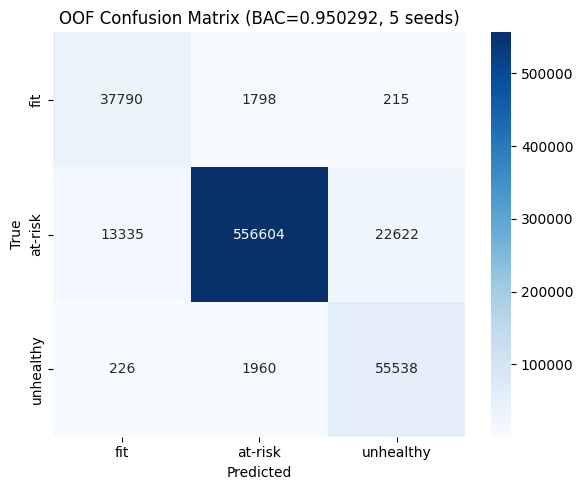

CPU times: user 3min 57s, sys: 2min 1s, total: 5min 59s
Wall time: 6min 1s


In [6]:
%%time

oof_sum    = np.zeros((N, 3), dtype=np.float64)
test_sum   = np.zeros((M, 3), dtype=np.float64)
all_fold_accs = []
X_oof_matrix = np.zeros((N, n_models * 3), dtype=np.float32)

for si, seed in enumerate(SEEDS):
    set_seed(seed)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    oof_this  = np.zeros((N, 3), dtype=np.float32)
    test_this = np.zeros((M, 3), dtype=np.float32)
    seed_accs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(N), y), start=1):
        t0 = time.time()

        meta_tr, meta_va = [], []
        for o in loaded_oofs:
            meta_tr.append(o[tr_idx, :])
            meta_va.append(o[val_idx, :])

        X_tr  = np.concatenate(meta_tr, axis=1).astype(np.float32)
        X_val = np.concatenate(meta_va, axis=1).astype(np.float32)

        if si == len(SEEDS) - 1:
            X_oof_matrix[val_idx, :] = X_val

        y_tr  = y[tr_idx]
        y_val = y[val_idx]

        classes = np.unique(y_tr)
        cw = compute_class_weight('balanced', classes=classes, y=y_tr)
        class_weight = dict(zip(classes, cw))
        class_weight[2] = class_weight[2] * BOOST
        sample_weights = np.array([class_weight[c] for c in y_tr], dtype=np.float32)

        X_tr_t  = torch.tensor(X_tr, dtype=torch.float32, device=device)
        y_tr_t  = torch.tensor(y_tr, dtype=torch.long, device=device)
        sw_t    = torch.tensor(sample_weights, dtype=torch.float32, device=device)
        X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)

        model = PyTorchMultiLogReg(in_features=X_tr.shape[1], out_features=3).to(device)
        criterion = nn.CrossEntropyLoss(reduction='none')
        weight_decay_mapped = 1.0 / (C * len(y_tr))
        optimizer = optim.Adam([
            {'params': model.linear.weight, 'weight_decay': weight_decay_mapped},
            {'params': model.linear.bias, 'weight_decay': 0.0},
        ], lr=0.01)

        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            logits = model(X_tr_t)
            loss = (criterion(logits, y_tr_t) * sw_t).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_prob = torch.softmax(model(X_val_t), dim=1).cpu().numpy()
            oof_this[val_idx] = val_prob
            test_this += torch.softmax(model(X_test_tensor), dim=1).cpu().numpy() / N_FOLDS

        fold_acc = balanced_accuracy_score(y_val, np.argmax(val_prob, axis=1))
        seed_accs.append(fold_acc)
        t1 = time.time()
        print(f"Seed {seed} fold {fold}: BAC={fold_acc:.6f} | {t1 - t0:.1f}s")

        del model, X_tr_t, y_tr_t, sw_t, X_val_t, X_tr, X_val
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    oof_sum  += oof_this
    test_sum += test_this

    seed_bac = balanced_accuracy_score(y, np.argmax(oof_this, axis=1))
    all_fold_accs.extend(seed_accs)
    print(f"Seed {seed}: OOF BAC={seed_bac:.6f} | folds={[f"{a:.6f}" for a in seed_accs]}")

oof_preds = (oof_sum / N_SEEDS).astype(np.float32)
test_preds = (test_sum / N_SEEDS).astype(np.float32)

oof_hard = np.argmax(oof_preds, axis=1)
overall = balanced_accuracy_score(y, oof_hard)
print(f'\nMean fold ACC across all {N_SEEDS * N_FOLDS} folds: {np.mean(all_fold_accs):.6f} +/- {np.std(all_fold_accs):.6f}')
print(f"Overall OOF Balanced ACC ({N_SEEDS}-seed avg): {overall:.6f}")

for k, label in inv_map.items():
    mask = (y == k)
    cls_acc = (oof_hard[mask] == k).mean()
    print(f"  {label:>6s} accuracy: {cls_acc:.6f}  ({(oof_hard[mask] == k).sum()}/{mask.sum()})")

cm = confusion_matrix(y, oof_hard)
print("\nConfusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(cm, index=[f'True {inv_map[i]}' for i in range(3)], columns=[f'Pred {inv_map[i]}' for i in range(3)]))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[inv_map[i] for i in range(3)],
            yticklabels=[inv_map[i] for i in range(3)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"OOF Confusion Matrix (BAC={overall:.6f}, {N_SEEDS} seeds)")
plt.tight_layout()
plt.show()

In [7]:
stack_name = f"lr_{n_models}_stacker_gpu_{str(np.round(overall, 6)).split('.')[1]}"

np.save(f"oof_{stack_name}.npy", oof_preds)
np.save(f"test_{stack_name}.npy", test_preds)

print(f"Saved oof_{stack_name}.npy  | {oof_preds.shape}")
print(f"Saved test_{stack_name}.npy | {test_preds.shape}")

submit = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv")
submit[TARGET] = np.argmax(test_preds, axis=1)
submit[TARGET] = submit[TARGET].map(inv_map)

submit.to_csv(f"{stack_name}_submission.csv", index=False)
print(f"\nSubmission saved: {stack_name}_submission.csv.csv")

print(submit[TARGET].value_counts())

submit

Saved oof_lr_84_stacker_gpu_950292.npy  | (690088, 3)
Saved test_lr_84_stacker_gpu_950292.npy | (295753, 3)

Submission saved: lr_84_stacker_gpu_950292_submission.csv.csv
health_condition
at-risk      241616
unhealthy     32332
fit           21805
Name: count, dtype: int64


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk


--- Training Dedicated 100% Data Model for Standardized Feature Importance ---

--- Standardized Model Feature Importances ---


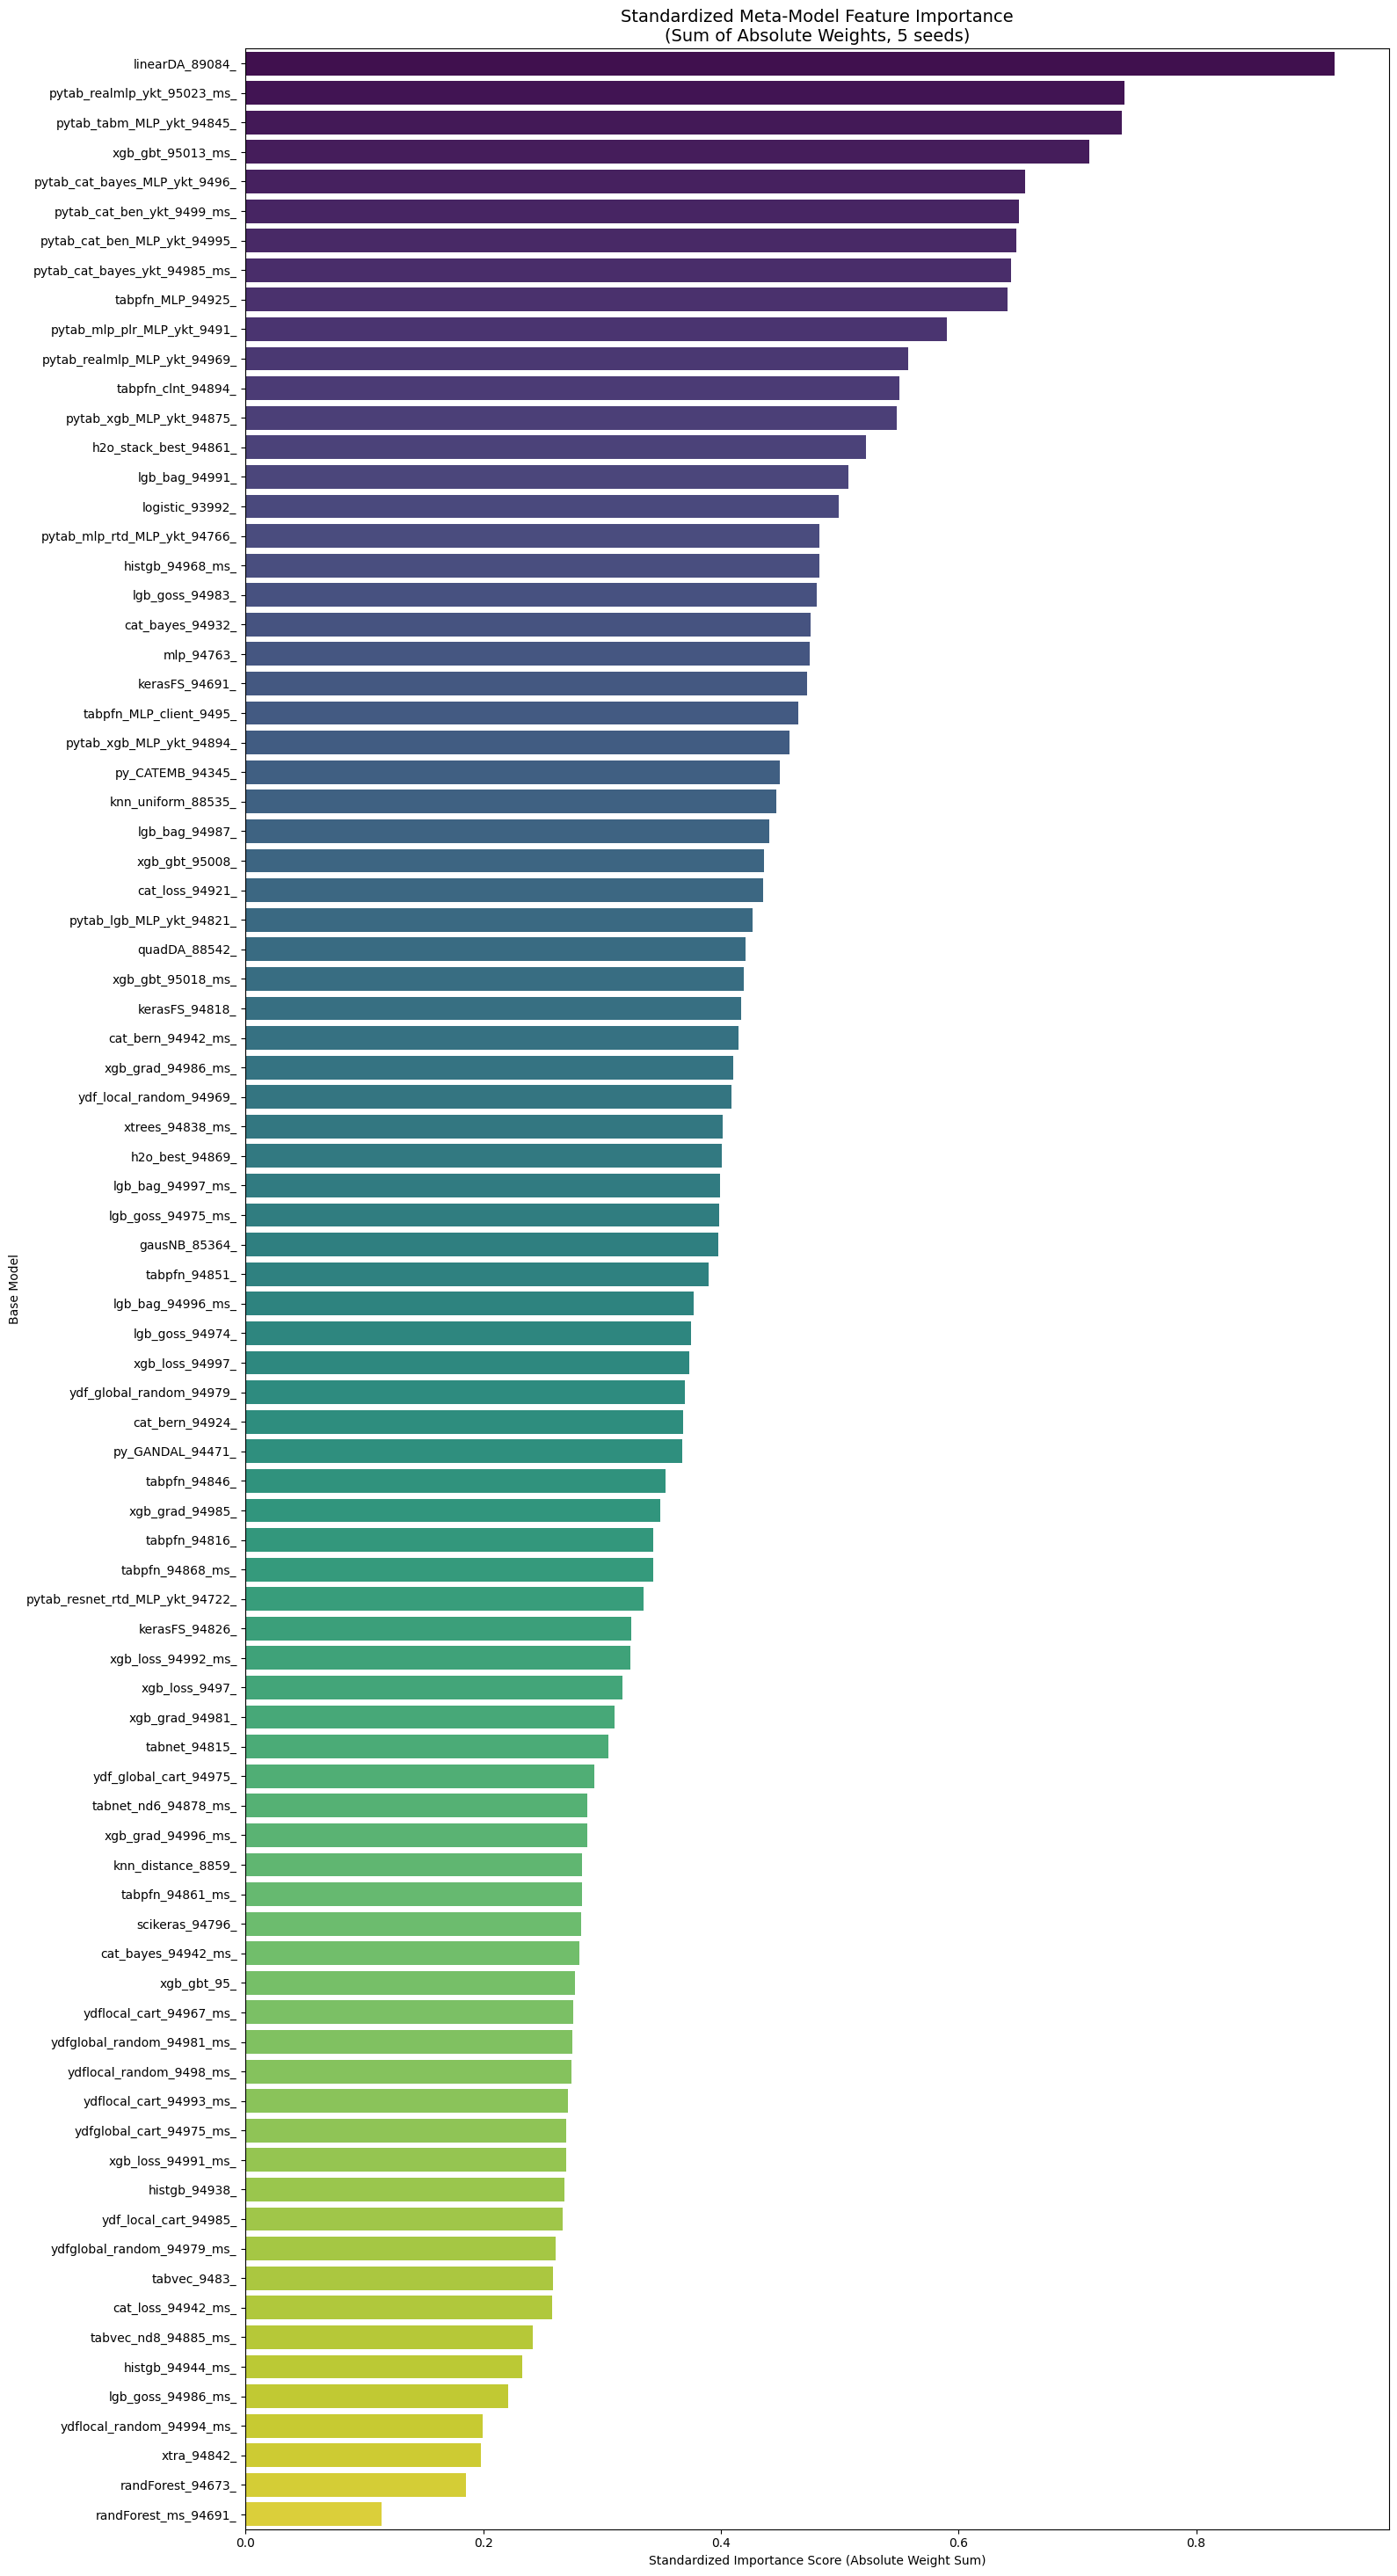

CPU times: user 12.1 s, sys: 7.11 s, total: 19.2 s
Wall time: 19.2 s


In [8]:
%%time

print("--- Training Dedicated 100% Data Model for Standardized Feature Importance ---")
scaler = StandardScaler()
X_oof_scaled = scaler.fit_transform(X_oof_matrix)

X_full_t = torch.tensor(X_oof_scaled, dtype=torch.float32, device=device)
y_full_t = torch.tensor(y, dtype=torch.long, device=device)

classes = np.unique(y)
cw = compute_class_weight('balanced', classes=classes, y=y)
class_weight = dict(zip(classes, cw))
class_weight[2] = class_weight[2] * BOOST
sw_full = np.array([class_weight[c] for c in y], dtype=np.float32)
sw_full_t = torch.tensor(sw_full, dtype=torch.float32, device=device)

imp_model = PyTorchMultiLogReg(in_features=X_oof_matrix.shape[1], out_features=3).to(device)
criterion = nn.CrossEntropyLoss(reduction='none')
C_imp = 1.0
weight_decay_mapped = 1.0 / (C_imp * len(y))
optimizer = optim.Adam([
    {'params': imp_model.linear.weight, 'weight_decay': weight_decay_mapped},
    {'params': imp_model.linear.bias, 'weight_decay': 0.0},
], lr=0.01)

imp_model.train()
for _ in range(epochs):
    optimizer.zero_grad()
    logits = imp_model(X_full_t)
    loss = (criterion(logits, y_full_t) * sw_full_t).mean()
    loss.backward()
    optimizer.step()

imp_weights = imp_model.linear.weight.detach().cpu().numpy()
del imp_model, X_full_t, y_full_t, sw_full_t
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print('\n--- Standardized Model Feature Importances ---')

model_importances = []
for i in range(n_models):
    block = imp_weights[:, i*3 : (i+1)*3]
    class_row_importance = np.sum(np.abs(block), axis=1)
    model_importances.append({
        'Model': display_names[i],
        'Total': float(class_row_importance.sum()),
        [*target_map.keys()][0]: float(class_row_importance[0]),
        [*target_map.keys()][1]: float(class_row_importance[1]),
        [*target_map.keys()][2]: float(class_row_importance[2]),
    })

df_imp = pd.DataFrame(model_importances)

plt.figure(figsize=(16, max(10, n_models * 0.35)))
sns.barplot(x='Total', y='Model', data=df_imp.sort_values(by='Total', ascending=False), palette='viridis')
plt.title(f'Standardized Meta-Model Feature Importance\n(Sum of Absolute Weights, {N_SEEDS} seeds)', fontsize=14)
plt.xlabel('Standardized Importance Score (Absolute Weight Sum)')
plt.ylabel('Base Model')
plt.tight_layout()
plt.show()

In [9]:
try:
    import optuna
except:
    %pip install -q optuna
    import optuna

def objective(trial):
    ## -- Random search class weights --
    cw0 = trial.suggest_float('cw0', 0.05, 1.0)  # Class weight 0
    cw1 = trial.suggest_float('cw1', 0.05, 1.0)  # Class weight 1
    cw2 = trial.suggest_float('cw2', 0.05, 1.0)  # Class weight 2
    
    ## Apply class weights
    class_weights = np.array([cw0, cw1, cw2])
    adjusted_probs = oof_preds * class_weights
    
    ## -- Get adjusted probabilities --
    adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)

    ## -- Compute metric --
    acc = balanced_acc(y, adjusted_probs)
    return acc

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=1313),
    study_name="class_weight_optimization"
)

## -- Start Search --
study.optimize(objective, n_trials=500, show_progress_bar=True)

[I 2026-07-31 23:14:46,188] A new study created in memory with name: class_weight_optimization


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-07-31 23:14:46,251] Trial 0 finished with value: 0.9156762009372924 and parameters: {'cw0': 0.9928772939069579, 'cw1': 0.079462469956358, 'cw2': 0.8583644196033829}. Best is trial 0 with value: 0.9156762009372924.
[I 2026-07-31 23:14:46,298] Trial 1 finished with value: 0.9483255858213924 and parameters: {'cw0': 0.9837437473854854, 'cw1': 0.24364333383826375, 'cw2': 0.5225431562060192}. Best is trial 1 with value: 0.9483255858213924.
[I 2026-07-31 23:14:46,347] Trial 2 finished with value: 0.9480542211706843 and parameters: {'cw0': 0.3138537210029509, 'cw1': 0.8911903187057085, 'cw2': 0.6723730520637681}. Best is trial 1 with value: 0.9483255858213924.
[I 2026-07-31 23:14:46,393] Trial 3 finished with value: 0.9404691984567582 and parameters: {'cw0': 0.8394318127227419, 'cw1': 0.10774746850970916, 'cw2': 0.6105243972007313}. Best is trial 1 with value: 0.9483255858213924.
[I 2026-07-31 23:14:46,443] Trial 4 finished with value: 0.9443813138517565 and parameters: {'cw0': 0.95647

In [10]:
best_score = np.round(study.best_value, 5)

print(f"\n{CFG['YELLOW']} • Optuna Best Score: {best_score}{CFG['RESET']}")
print("\nClass Weights:")
print(f"  class_0 = {study.best_params['cw0']:.5f}")
print(f"  class_1 = {study.best_params['cw1']:.5f}")
print(f"  class_2 = {study.best_params['cw2']:.5f}")

## -- Get best weight per class --
best_cw = np.array([study.best_params['cw0'], 
                    study.best_params['cw1'], 
                    study.best_params['cw2']])

## -- Apply best weights to test predictions --
final_test_probs = test_preds * best_cw
final_test_probs = final_test_probs / final_test_probs.sum(axis=1, keepdims=True)

## -- Get final labels --
final_test_preds = np.argmax(final_test_probs, axis=1)

## -- Save submission file --
file_name = f"lr_{n_models}_stacker_gpu_optim_weights_{str(best_score).split('.')[1]}.csv"
# file_name = f"submit_optim_weights_Optuna_{str(best_score).split('.')[1]}.csv"

submit[TARGET] = pd.Series(final_test_preds).map(inv_map)
submit.to_csv(file_name, index=False)
submit


 • Optuna Best Score: 0.95045

Class Weights:
  class_0 = 0.89718
  class_1 = 0.78477
  class_2 = 0.85323


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk
